<a href="https://colab.research.google.com/github/arisaenokido/Voting_Behavior_Analysis/blob/main/Econ_227_Voting_Behavior_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Final Project

Arisa Enokido, Ryder Ilich, Kabir Jain, Ben Seethaler, Sriram Susarla

2025-12-08

### Our research question
We are interested in researching potential correlation between income and voting patterns in Canada across electoral districts. Ultimately, we came to the research question is whether a Canadian federal election riding’s voting decisions correlate with its median individual income? If so, which parties are associated with what levels of income? We focused on the 2021 federal election to answer this question.

### R Preparation

In [ ]:
#load packages
library(tidyverse)
library(haven)
install.packages('gt')
library(gt)

#load in data
data <- read_csv("ridingdataset.csv")


#clean up
d = 5000
data <- data %>%
#Making sure all percentages are read as numbers instead of strings
mutate(
    Province = as_factor(Province),
    `Electoral District` = as_factor(`Electoral District`),
    `% votes CPC` = as.numeric(`% votes CPC`),
    `% votes LPC` = as.numeric(`% votes LPC`),
    `% votes GPC` = as.numeric(`% votes GPC`),
    `% votes NDP` = as.numeric(`% votes NDP`),
#Assigning a tag to income brackets in steps of 5000
    bin = case_when(
          `Median Income` <= 30000 + 1*d ~ "A",
          `Median Income` <= 30000 + 2*d ~ "B",
          `Median Income` <= 30000 + 3*d ~ "C",
          `Median Income` <= 30000 + 4*d ~ "D",
          `Median Income` <= 30000 + 5*d ~ "E",
          `Median Income` <= 30000 + 6*d + 1500 ~ "F", #Group expanded to include Fort McMurrary, which was only a thousand dollars above the top bracket

    ),
#Defining differences to show winning party for each riding. Used for the boxplots.
    winner = case_when(
        `% votes GPC` > `% votes CPC` & `% votes GPC` > `% votes LPC` & `% votes GPC` > `% votes NDP` ~ "Other",
        `% votes NDP` > `% votes CPC` & `% votes NDP` > `% votes LPC`  & `% votes NDP` > `% votes GPC` ~ "Other",
        `% votes LPC` > `% votes CPC` ~ "LPC",
        `% votes CPC` > `% votes LPC` ~ "CPC",
    ),
#Calculates total votes overall
  TotalVotes = as.numeric(`#votes for CPC`)+as.numeric(`#votes for LPC`)+as.numeric(`#votes for NDP`)+as.numeric(`#votes for Bloc`)+as.numeric(`#votes for GPC`)+as.numeric(`#votes for PPC`)
)%>%
  rename(
    `% votes PPC` = `%votes PPC`
  )



── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
also installing the dependencies ‘xfun’, ‘V8’, ‘litedown’, ‘reactR’, ‘bigD’, ‘juicyjuice’, ‘markdown’, ‘reactable’




### Table of Statistics



In [ ]:
#Preparing gt-table to work
gt_show <- function(gt_table){
   gt:::as.tags.gt_tbl(gt_table)
}
#Building a table of summary statistics utilizing mean, median, minimum, maximum, and standard deviation for our main focuses: Median Income, % Votes for CPC, and % Votes for LPC
tableBasicStats <- tibble(
    Statistics=c("Mean", "Median", "Min", "Max", "SD"),
    `Median Income (CAD)` =  c(mean(data$`Median Income`), median(data$`Median Income`), min(data$`Median Income`), max(data$`Median Income`), sd(data$`Median Income`)),
    `% votes CPC` =  c(mean(data$`% votes CPC`), median(data$`% votes CPC`), min(data$`% votes CPC`), max(data$`% votes CPC`), sd(data$`% votes CPC`)),
    `% votes LPC` =  c(mean(data$`% votes LPC`), median(data$`% votes LPC`), min(data$`% votes LPC`), max(data$`% votes LPC`), sd(data$`% votes LPC`))
)

tableBasicStats %>%
  gt() %>%
  gt_show()


Statistics,Median Income (CAD),% votes CPC,% votes LPC
Mean,41431.454,33.70062,33.72884
Median,41200.000,32.72000,34.69000
Min,30000.000,0.00000,4.31000
Max,61200.000,78.21000,71.93000
SD,5080.995,16.72445,15.31336


### Scatterplots

In the following scatterplot, each point represents a single federal riding and its color corresponds to its province.

`geom_smooth()` using formula = 'y ~ x'


(Intercept) `Median Income` 
  64.8686129305   -0.0007515973


Call:
lm(formula = `% votes LPC` ~ `Median Income`, data = data)

Residuals:
    Min      1Q  Median      3Q     Max 
-29.607 -12.305   0.986  13.004  31.714 

Coefficients:
                  Estimate Std. Error t value Pr(>|t|)    
(Intercept)     64.8686129  6.6560805   9.746  < 2e-16 ***
`Median Income` -0.0007516  0.0001595  -4.713 3.58e-06 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 14.85 on 335 degrees of freedom
Multiple R-squared:  0.06219,	Adjusted R-squared:  0.05939 
F-statistic: 22.22 on 1 and 335 DF,  p-value: 3.579e-06


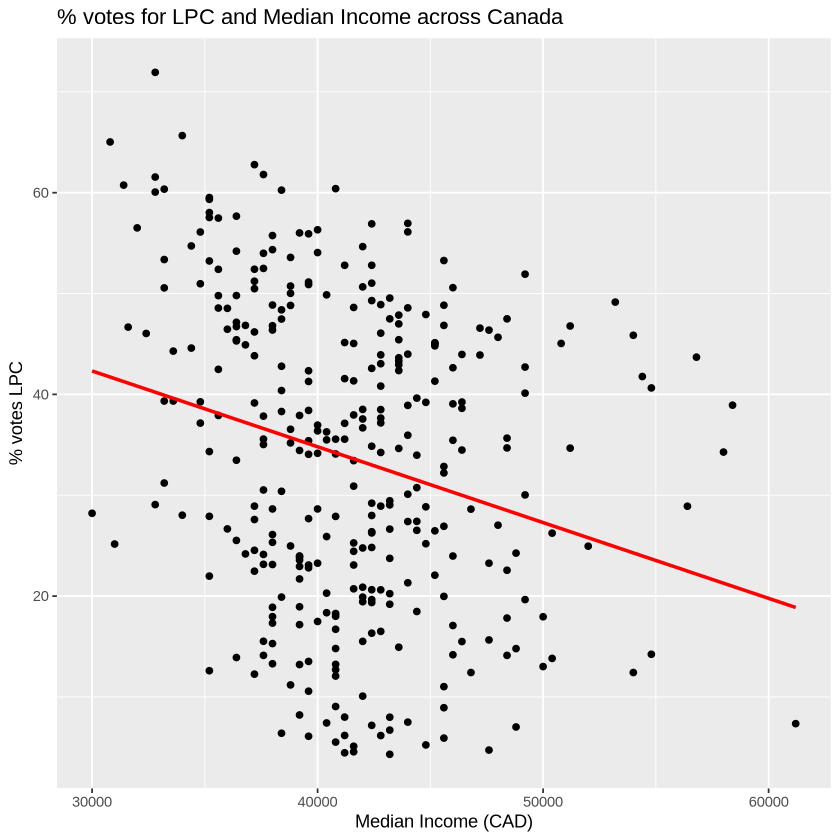

In [ ]:
#Using ggplot to build scatterplots using cleaned data from the first cell. X-axis shows median income, while the y-axis is for % votes to the winning party in that riding.
canadascatterLPC <- ggplot(data=data, aes(x=`Median Income`, y=`% votes LPC`,))
canadascatterLPC <- canadascatterLPC + labs(x="Median Income (CAD)", y="% votes LPC", title="% votes for LPC and Median Income across Canada")
#Turning the labeled data into a scatter plot, adding a trend line, removing the confidence interval, and then plotting the scatterplot
canadascatterLPC <- canadascatterLPC + geom_point() + geom_smooth(method = "lm", se = FALSE, color = "red")
canadascatterLPC
model <- lm(`% votes LPC` ~ `Median Income`, data=data)
coef(model)
summary(model)

## LPC:
This scatterplot shows the relationship between median individual income and the % votes for the LPC. Each point represents a riding at a particular income and voting level. By examining the visualization, we observe a weak negative correlation between these two, but overall we see how the LPC gains more support from lower median income individuals. This also supports our research question as we can see that median individual income is correlated with the Liberal Party's outcome.

`geom_smooth()` using formula = 'y ~ x'


(Intercept) `Median Income` 
   6.5287249807    0.0006558278


Call:
lm(formula = `% votes CPC` ~ `Median Income`, data = data)

Residuals:
    Min      1Q  Median      3Q     Max 
-34.336 -12.849  -0.246  12.316  43.350 

Coefficients:
                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)     6.5287250  7.3560848   0.888 0.375432    
`Median Income` 0.0006558  0.0001762   3.721 0.000232 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 16.41 on 335 degrees of freedom
Multiple R-squared:  0.0397,	Adjusted R-squared:  0.03683 
F-statistic: 13.85 on 1 and 335 DF,  p-value: 0.0002323


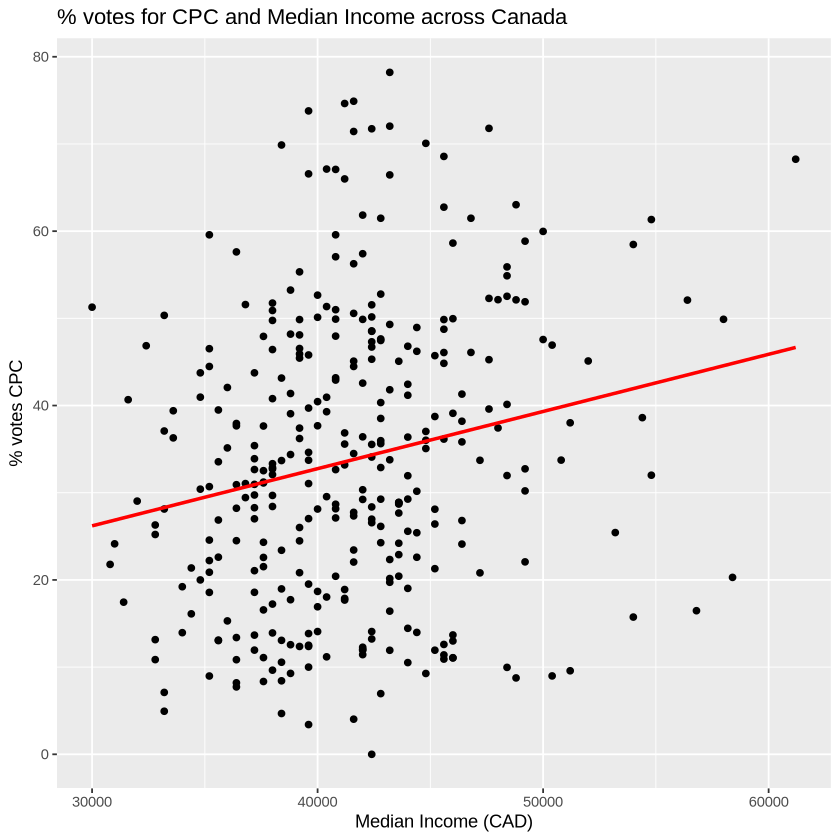

In [ ]:
#Redo the same process as the previous cell regarding the Conservative Party
canadascatterCPC <- ggplot(data=data, aes(x=`Median Income`, y=`% votes CPC`,))
canadascatterCPC <- canadascatterCPC + labs(x="Median Income (CAD)", y="% votes CPC", title="% votes for CPC and Median Income across Canada")
canadascatterCPC <- canadascatterCPC + geom_point() + geom_smooth(method = "lm", se = FALSE, color = "red")
canadascatterCPC
model <- lm(`% votes CPC` ~ `Median Income`, data=data)
coef(model)
summary(model)

## CPC
This scatterplot shows the relationship between median individual income and % votes for the CPC. Again, every point on this graph represents a riding. Based on the visualization, we can see that there is a positive but low correlation between these two variables. But generally, the CPC gains more support in higher median income individuals. This ties socioeconomic status to vote choice, and we can see that income does to an extent correlate CPC outcome.

In [ ]:
#Getting png files for the poster.
ggsave("scatterplotLPC.png", plot=canadascatterLPC)
ggsave("scatterplotCPC.png", plot=canadascatterCPC)

Saving 6.67 x 6.67 in image
`geom_smooth()` using formula = 'y ~ x'
Saving 6.67 x 6.67 in image
`geom_smooth()` using formula = 'y ~ x'


### Bar Charts

Shiny tags cannot be represented in plain text (need html)

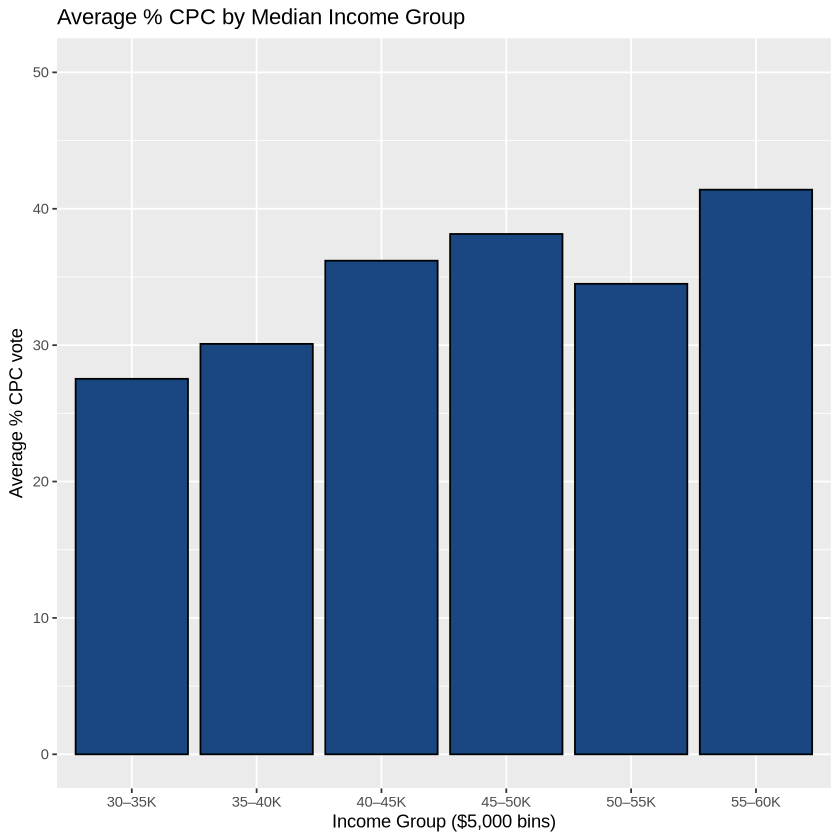

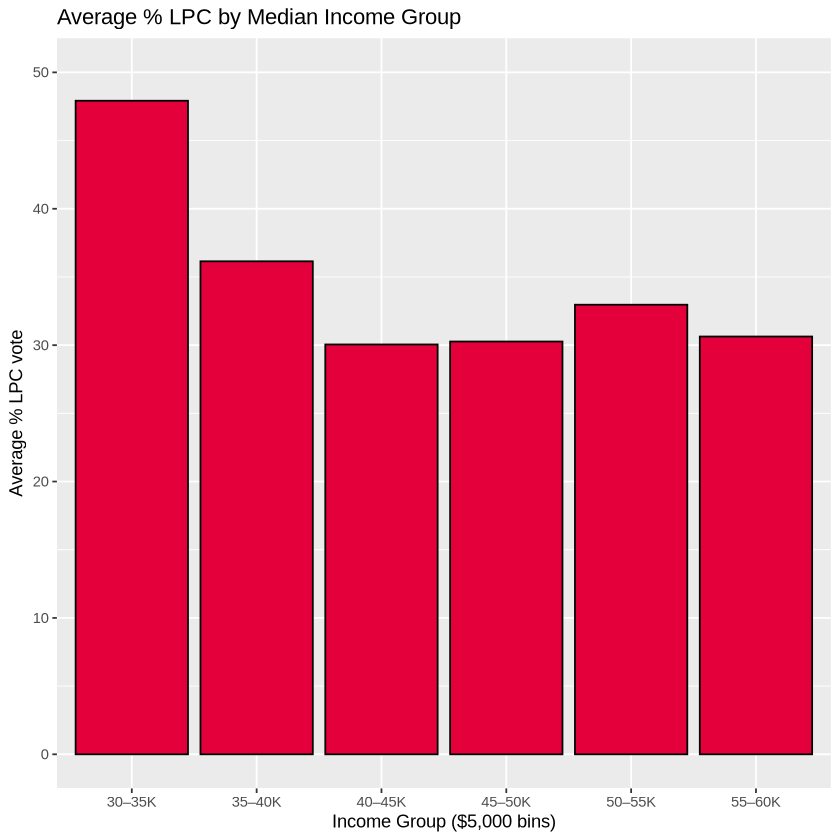

In [ ]:
#Grouping out data into bins by winning party and finding the average voting for the winning party in each bin.
group_dataLPC <- data %>%
    group_by(bin) %>%
    summarize(
        n=n(),
        avg_LPC_percent = mean(`% votes LPC`),
    )

group_dataCPC <- data %>%
    group_by(bin) %>%
    summarize(
        avg_CPC_percent = mean(`% votes CPC`),
    )
#using innerjoin to combine the bins into one table
group_data <- inner_join(group_dataLPC, group_dataCPC, by="bin")
group_data <- group_data %>%
#Labeling bins by the income category to make the table and bar charts easier to interpret
  mutate(bin = factor(bin,
                      levels = c("A","B","C","D","E","F"),
                      labels = c("30–35K","35–40K","40–45K",
                                 "45–50K","50–55K","55–60K")
  ))

#head(group_data)

#Using ggplot to build the barchart. Bins by income category on the x-axis, avg votes for the winning party on the y-axis,
barchartA <- ggplot(group_data, aes(x =bin, y = avg_CPC_percent)) +
  geom_col(color="black", fill="#1A4782") +
  ylim(0,50)+
labs(
    x = "Income Group ($5,000 bins)",
    y = "Average % CPC vote",
    title = "Average % CPC by Median Income Group"
  )

#calculate percent change using the lag function
#reorder columns so we can pass the right data frame through gt
gt_show <- function(gt_table){
   gt:::as.tags.gt_tbl(gt_table)
}
percent_change_table <- group_data %>%
  arrange(bin) %>%
  mutate(
    CPC_pct_change = (avg_CPC_percent - lag(avg_CPC_percent)) / lag(avg_CPC_percent) * 100,
    LPC_pct_change = (avg_LPC_percent - lag(avg_LPC_percent)) / lag(avg_LPC_percent) * 100
  ) %>%
 select(
    bin,
    n,
    avg_LPC_percent,
    LPC_pct_change,
    avg_CPC_percent,
    CPC_pct_change
  )
gt(percent_change_table)%>%
cols_label(
   bin  = "Income Bracket",
    n = "Number of Ridings",
    avg_LPC_percent = "Avg LPC Vote Share %",
    avg_CPC_percent = "Avg CPC Vote Share %",
    CPC_pct_change = "CPC Percent Change in Vote Share %",
    LPC_pct_change = "LPC Percent Change in Vote Share %",
  ) %>%
tab_header(
    title= "Percent Change in Average Vote Share by Party"
    )%>%
fmt_number(
    columns = c(avg_LPC_percent, LPC_pct_change,
                avg_CPC_percent, CPC_pct_change),
    decimals = 2
  ) %>%
gt_show()
#Chart and axes titles given as well

barchartB <- ggplot(group_data, aes(x = bin, y = avg_LPC_percent)) +
  geom_col(color="black", fill="#E4003B") +
  ylim(0,50)+
labs(
    x = "Income Group ($5,000 bins)",
    y = "Average % LPC vote",
    title = "Average % LPC by Median Income Group"
  )

barchartA
barchartB

# Bar Chart Analysis
## CPC:  
The first bar chart, Average % CPC by Median Income Group provides further evidence toward our research question. This visualization shows a remarkably clear pattern between voting for the Conservative Party, and higher median incomes. Each income group shows a higher level of support for the CPC compared to its poorer counterparts, rising from 27% to 42%. The pattern is consistent with the exception of the 50-50K group, which has a lower vote share for the CPC than the 45-50K group. This exception may be partially attributable to the low number of observations in these two groups, only 17 in total, creating less conclusive findings. This visualization helps to answer the research question, by clearly showing that median income is at least partially linked to Conservative Party electoral success.

## LPC:
Average % LPC by Median Income Group effectively describes voting patterns across Canadian electoral ridings. As can be observed, the party fares better in ridings with relatively low median incomes, with their average vote share in the poorest group at 47% falling to 33% among the richest ridings. However, other than the fact that the poorest group strongly favour the LPC, the party has a much more consistent showing between all other income groups, ranging between 29% and 37%. However, the richest two groups do have relatively few data points(12 and 5), allowing for less meaningful insight. This provides meaningful evidence toward answering our research question, since it demonstrates that there is a connection between Canadian voting patterns and median incomes, which in the case of the Liberal Party is a connection between poor ridings and high vote shares.



### Boxplot for Non-Quebec Ridings by Party

Shiny tags cannot be represented in plain text (need html)

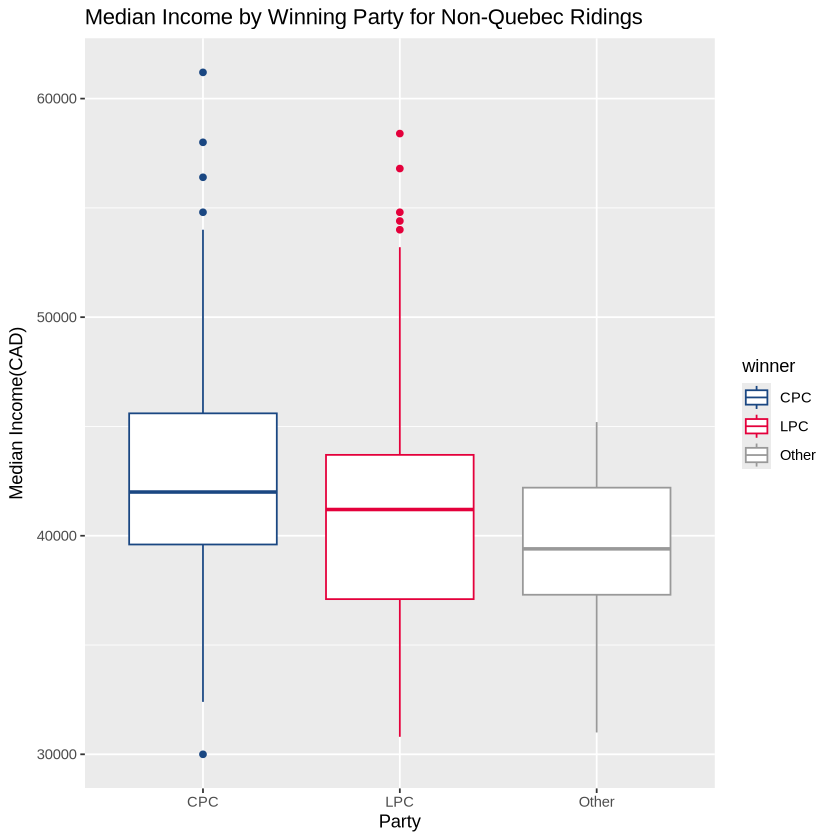

In [ ]:
#boxplot. we filter data to not include Quebec in order to prevent dealing with the regional parties of Quebec.
#Used winner classifications from above to separate Liberals, Conservative, and Other, plotting those on  the x axis, and income on the y-axis
#Used official Canadian party color codes and added chart and axes titles

boxplot <- ggplot(data=filter(data, `Province`!= "Quebec"), aes(x=winner, y=`Median Income`, color = winner))
boxplot <- boxplot + geom_boxplot()
boxplot <- boxplot + scale_color_manual(values=c("#1A4782", "#E4003B", "#999999"))
boxplot <- boxplot + labs(title="Median Income by Winning Party for Non-Quebec Ridings", y="Median Income(CAD)", x="Party")
boxplot

#Summary statistics by party. Gives a glimpse into which parties attract what kind of incomes.
summary_boxplot <- data %>%
  filter(Province != "Quebec") %>%
  group_by(winner) %>%
  summarise(
    mean_income = mean(`Median Income`),
    median_income = median(`Median Income`),
    sd_income = sd(`Median Income`),
    var_income = var(`Median Income`),
    min_income = min(`Median Income`),
    max_income = max(`Median Income`),
    n = n()
  )

#build a summary statistics table with basic numeral analysis
#use gt functions to get pretty labels and no rounding needed
gt_show <- function(gt_table){
   gt:::as.tags.gt_tbl(gt_table)
}

  gt(summary_boxplot) %>%
cols_label(
    mean_income   = "Mean Median Income",
    median_income = "Median Median Income",
    sd_income = "SD Median Income",
    var_income    = "Variance Median Income",
    min_income = "Minimum Median Income",
    max_income = "Maximum Median Income",
    winner = "Winning Party"
  ) %>%
tab_header(
    title= "Median Income Summary Statistics by Party"
    )%>%
  gt_show()


### Boxplot Analysis
The boxplot that we have created displays the distribution of median incomes across ridings the parties won. We chose to exclude Quebec ridings as they have a unique party, Bloc Québecois. Therefore, we have our three key variables: Conservative Party of Canada (CPC), Liberal Party of Canada(LPC), and all of the other parties (Greens and NDP), labeled “Other”. This visualization shows us that the LPC earns more support than the CPC in lower median income districts. The interquartile range, so the 25th to 75th percentile range of the Conservative Party is visibly higher compared to the LPC and other parties, showing that CPC earns support in higher income districts, confirming our research question, where we can see correlation between median individual income and vote choice.


In [ ]:
#save boxplot as png
ggsave("boxplot.png", plot=boxplot)

**References:**


Government of Canada, & Canada, S. (2022, February 9). Census Profile, 2021 Census of Population. https://www12.statcan.gc.ca/census-recensement/2021/dp-pd/prof/index.cfm?Lang=E


The Canadian Press. (2021, September 20). Canadian federal election results 2021: A riding-by-riding breakdown of the vote. National Post. https://nationalpost.com/news/politics/election-2021/federal-election-results-2021-justin-trudeau-erin-otoole-jagmeet-singh